# 03 - Experiment validity and power

**Goal:** before looking at any outcome, check whether the experiment itself is
trustworthy, and work out how sensitive it was.

Beginners jump straight to p-values. The two questions that come first are
"can I trust this experiment?" (sample ratio mismatch, data quality) and
"what could this test even have detected?" (minimum detectable effect and power).

In [1]:
import pandas as pd                                  # tables
import numpy as np                                   # maths
import matplotlib.pyplot as plt                      # charts
from scipy import stats                              # statistical tests and distributions
from statsmodels.stats.power import NormalIndPower   # power calculations
from statsmodels.stats.proportion import proportion_effectsize   # converts two rates into an effect size
from pathlib import Path                             # file paths

pd.set_option("display.max_columns", None)           # never hide columns when printing tables
pd.set_option("display.width", 200)                  # allow wide tables to print on one line

In [2]:
ROOT = Path.cwd()                                    # folder the notebook runs in
if ROOT.name == "notebooks":                         # if inside notebooks/...
    ROOT = ROOT.parent                               # ...go up to the project root
FIG_DIR = ROOT / "reports" / "figures"               # charts folder
df = pd.read_csv(ROOT / "data" / "processed" / "cookie_cats_clean.csv")   # load the cleaned data from notebook 02
print(df.shape)                                      # expect (90189, 8)

(90189, 8)


## Sample ratio mismatch (SRM)

SRM asks whether the group sizes differ from the intended split by more than chance
would explain. A real SRM can mean a bug in assignment or in logging, which could bias
every result, so it is checked before any outcome is looked at.

In [3]:
observed = df["version"].value_counts().sort_index()          # players per group, sorted so gate_30 comes first
total_players = observed.sum()                                # total players in the test
intended_split = np.array([0.5, 0.5])                         # ASSUMPTION: the test was designed as 50/50
expected = total_players * intended_split                     # how many players each group should have under 50/50
chi2_stat, srm_p_value = stats.chisquare(f_obs=observed.values, f_exp=expected)   # chi-square goodness-of-fit test
print("Observed:", observed.to_dict())                        # actual counts
print("Expected:", dict(zip(observed.index, expected.round(1).tolist())))   # counts we expected under 50/50
print("Chi-square statistic:", round(chi2_stat, 3))           # how far observed is from expected
print("SRM p-value:", round(srm_p_value, 5))                  # probability of an imbalance this large if the split were truly 50/50

Observed: {'gate_30': 44700, 'gate_40': 45489}
Expected: {'gate_30': 45094.5, 'gate_40': 45094.5}
Chi-square statistic: 6.902
SRM p-value: 0.00861


**Checkpoint:** chi-square statistic 6.902, SRM p-value 0.00861.

In [4]:
for threshold in [0.05, 0.01, 0.001]:                         # loop over three commonly used thresholds
    flagged = srm_p_value < threshold                         # True if the p-value is below this threshold
    print(f"Threshold {threshold}: SRM flagged = {flagged}")  # show the decision at each threshold

Threshold 0.05: SRM flagged = True
Threshold 0.01: SRM flagged = True
Threshold 0.001: SRM flagged = False


**Checkpoint:** flagged at 0.05 and 0.01, not flagged at 0.001.

- If the test was designed as 50/50, an imbalance of 789 players or larger would happen
  by chance less than 1% of the time.
- Many experimentation platforms only raise an SRM alarm at p < 0.001, because the check
  runs on every experiment and a looser cutoff would raise too many false alarms.
  So this result is **borderline**: not an automatic failure, but something to report.
- **Possible causes in real life:** a bug in how players were assigned, one version logging
  less reliably, or bot filtering that hit one group harder.
- **What we do:** continue, state the SRM result clearly in the memo, and list it as a
  limitation. The data has no assignment logs or timestamps, so it cannot be investigated further here.

In [5]:
df["userid_decile"] = pd.qcut(df["userid"], q=10, labels=False)          # split players into 10 equal-sized userid bands (0 to 9)
decile_table = pd.crosstab(df["userid_decile"], df["version"])           # count gate_30 and gate_40 players in each band
decile_table["gate_40_share_pct"] = 100 * decile_table["gate_40"] / (decile_table["gate_30"] + decile_table["gate_40"])  # % of the band in gate_40
decile_p_values = []                                                     # empty list to collect one p-value per band
for decile in decile_table.index:                                        # loop over the 10 bands
    counts = decile_table.loc[decile, ["gate_30", "gate_40"]].values     # the two counts in this band
    band_p = stats.chisquare(counts, f_exp=[counts.sum() / 2, counts.sum() / 2]).pvalue   # SRM test inside this band
    decile_p_values.append(band_p)                                       # store the p-value
decile_table["srm_p_value"] = decile_p_values                            # add the p-values as a column
print(decile_table.round(4))                                             # show the table

version        gate_30  gate_40  gate_40_share_pct  srm_p_value
userid_decile                                                  
0                 4474     4545            50.3936       0.4547
1                 4486     4533            50.2606       0.6207
2                 4507     4512            50.0277       0.9580
3                 4542     4477            49.6396       0.4937
4                 4391     4628            51.3139       0.0126
5                 4471     4547            50.4214       0.4235
6                 4487     4532            50.2495       0.6356
7                 4474     4545            50.3936       0.4547
8                 4450     4569            50.6597       0.2102
9                 4418     4601            51.0145       0.0540


**Checkpoint:** gate_40 holds more than 50% in 9 of the 10 bands, and only one band has a
p-value below 0.05 (about 0.013).

If one band carried a huge imbalance, that would point at a bug in a specific ID range.
Instead the small tilt toward gate_40 is spread fairly evenly. This is exploratory only,
because nothing in the data confirms that user IDs follow install order.

## Minimum detectable effect (MDE) and power

The MDE is the smallest true effect this sample size could detect with alpha = 0.05 and
80% power. It is what turns "not significant" into a precise statement.

In [6]:
alpha = 0.05                                          # significance level from the pre-analysis plan
power = 0.80                                          # desired power from the pre-analysis plan
z_alpha = stats.norm.ppf(1 - alpha / 2)               # z value for a two-sided test (about 1.96)
z_power = stats.norm.ppf(power)                       # z value for 80% power (about 0.84)
n_control = observed["gate_30"]                       # players in control
n_treatment = observed["gate_40"]                     # players in treatment
mde_rows = []                                         # empty list to collect results
for metric in ["retention_1", "retention_7"]:         # loop over both retention metrics
    baseline = df.loc[df["version"] == "gate_30", metric].mean()                 # control retention rate
    std_error = np.sqrt(baseline * (1 - baseline) * (1 / n_control + 1 / n_treatment))   # standard error of the difference under H0
    mde_abs = (z_alpha + z_power) * std_error                                    # smallest absolute difference we can reliably detect
    mde_rows.append({"metric": metric, "baseline_pct": 100 * baseline, "mde_abs_pp": 100 * mde_abs, "mde_relative_pct": 100 * mde_abs / baseline})  # store in percent units
mde_table = pd.DataFrame(mde_rows)                    # turn the list into a table
print(mde_table.round(3))                             # show MDE per metric

        metric  baseline_pct  mde_abs_pp  mde_relative_pct
0  retention_1        44.819       0.928              2.07
1  retention_7        19.020       0.732              3.85


**Checkpoint:** D1 MDE about 0.928 pp (2.07% relative). D7 MDE about 0.732 pp (3.85% relative).

With about 45,000 players per group the test had an 80% chance of spotting a true D7 change
of 0.73 pp or larger. Smaller true changes, such as the 0.5 pp the plan calls meaningful,
could easily be missed. A non-significant result therefore means "no effect larger than
roughly the MDE was detected", not "no effect".

In [7]:
baseline_d7 = df.loc[df["version"] == "gate_30", "retention_7"].mean()          # control D7 rate
ratio = n_treatment / n_control                                                  # group size ratio (treatment / control)
effect_size_h = NormalIndPower().solve_power(nobs1=n_control, alpha=alpha, power=power, ratio=ratio, alternative="two-sided")  # solves for Cohen's h
detectable_rate = np.sin(np.arcsin(np.sqrt(baseline_d7)) - effect_size_h / 2) ** 2   # convert h back into a retention rate (a decrease)
print("Cohen's h:", round(effect_size_h, 5))                                     # effect size in standardized units
print("Detectable D7 rate:", round(100 * detectable_rate, 3), "% vs baseline", round(100 * baseline_d7, 3), "%")   # rate we could detect
print("Implied MDE (pp):", round(100 * (baseline_d7 - detectable_rate), 3))      # should be close to the formula above

Cohen's h: 0.01866
Detectable D7 rate: 18.293 % vs baseline 19.02 %
Implied MDE (pp): 0.727


**Checkpoint:** Cohen's h about 0.01866 and an implied MDE about 0.727 pp, very close to the
formula result. The tiny gap comes from the two methods using slightly different approximations.

In [8]:
target_drop = 0.005                                    # 0.5 percentage points written as a proportion
p1 = baseline_d7                                       # control rate
p2 = baseline_d7 - target_drop                         # treatment rate we want to be able to detect
n_per_group = ((z_alpha + z_power) ** 2) * (p1 * (1 - p1) + p2 * (1 - p2)) / (p1 - p2) ** 2   # standard sample-size formula
print("Players needed per group:", int(np.ceil(n_per_group)))                    # round up to a whole player
h_target = proportion_effectsize(p1, p2)                                         # same question using statsmodels
n_statsmodels = NormalIndPower().solve_power(effect_size=h_target, alpha=alpha, power=power, ratio=1.0, alternative="two-sided")  # solve for sample size
print("statsmodels answer:", int(np.ceil(n_statsmodels)))                        # should be very close

Players needed per group: 95734
statsmodels answer: 95734


**Checkpoint:** 95,734 players per group from both methods.

To reliably detect the 0.5 pp change the plan calls meaningful, the test would have needed
about 95,700 players per group, more than twice what it had. This is exactly the calculation
used to advise a team on how long to run their next test.

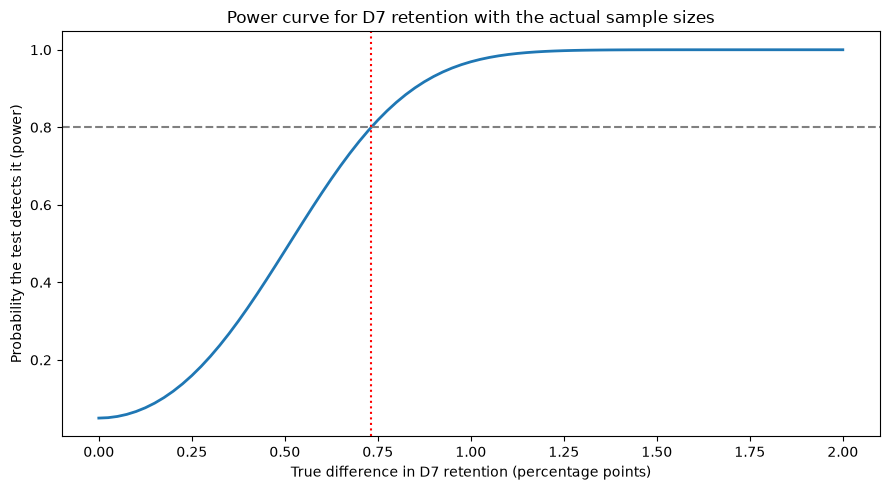

In [9]:
true_differences = np.linspace(0.0, 0.02, 81)          # true drops from 0 to 2 percentage points (81 points)
powers = []                                            # empty list for the power values
se_d7 = np.sqrt(baseline_d7 * (1 - baseline_d7) * (1 / n_control + 1 / n_treatment))   # standard error of the D7 difference
for diff in true_differences:                          # loop over each possible true difference
    z_shift = diff / se_d7                             # how many standard errors the true difference is
    power_value = stats.norm.cdf(z_shift - z_alpha) + stats.norm.cdf(-z_shift - z_alpha)   # two-sided power formula
    powers.append(power_value)                         # store it
fig, ax = plt.subplots(figsize=(9, 5))                 # empty chart
ax.plot(100 * true_differences, powers, linewidth=2)   # power curve (x in percentage points)
ax.axhline(0.80, linestyle="--", color="grey")         # 80% power reference line
ax.axvline(mde_table.loc[1, "mde_abs_pp"], linestyle=":", color="red")   # our D7 MDE
ax.set_xlabel("True difference in D7 retention (percentage points)")      # x label
ax.set_ylabel("Probability the test detects it (power)")                  # y label
ax.set_title("Power curve for D7 retention with the actual sample sizes") # title
fig.tight_layout()                                     # tidy
fig.savefig(FIG_DIR / "04_power_curve_d7.png", dpi=150)   # save
plt.show()                                             # display

Power rises as the true difference grows, and the curve crosses the dashed 80% line at the MDE.

Power analysis belongs to planning and to understanding sensitivity. Computing "observed power"
from the result already in hand adds no information, so it is not done here.